# Credit Card Approval Analysis and Prediction

**Internship Project**
**Author:** Maniha Munawar

This notebook builds a machine learning system that classifies credit card
applicants as **Good Credit** or **Risky Credit**, based on the
[Credit Card Approval Prediction dataset](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)
from Kaggle.

**Note:** This dataset does not provide a ready-made "Approved/Rejected"
label. Instead, this project builds a credit-risk classification target
from applicants' repayment history, as explained in the Target Variable
section below. This is why the project is best understood as a
*credit-risk classification* system used as a proxy for approval-worthiness,
not a simulation of an actual bank's internal decision process.

## Contents
1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Merging the Datasets
5. Target Variable Creation
6. Feature Engineering
7. Exploratory Data Analysis
8. Data Preprocessing
9. Train/Test Split
10. Model Training
11. Model Evaluation & Comparison
12. Final Model Selection & Saving


## 1. Data Loading

We load both raw CSV files provided by the Kaggle dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

application_df = pd.read_csv('../data/application_record.csv')
credit_df = pd.read_csv('../data/credit_record.csv')

print("application_record.csv shape:", application_df.shape)
print("credit_record.csv shape:", credit_df.shape)

application_record.csv shape: (438557, 18)
credit_record.csv shape: (1048575, 3)


## 2. Data Understanding

`application_record.csv` contains one row per applicant with demographic
and financial information. `credit_record.csv` contains one row per
applicant *per month*, with a `STATUS` column describing how many days
(if any) a payment was overdue that month.

Let's look at both in detail.

In [2]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [4]:
application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [5]:
credit_df.head(10)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [6]:
credit_df['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

**STATUS code meanings:**

| STATUS | Meaning |
|---|---|
| 0 | 1-29 days past due |
| 1 | 30-59 days past due |
| 2 | 60-89 days past due |
| 3 | 90-119 days past due |
| 4 | 120-149 days past due |
| 5 | Overdue 150+ days / bad debt |
| C | Paid off that month |
| X | No loan that month |


In [7]:
print("Missing values in application_record:")
print(application_df.isnull().sum()[application_df.isnull().sum() > 0])
print()
print("Missing values in credit_record:")
print(credit_df.isnull().sum().sum(), "total missing values")

Missing values in application_record:
OCCUPATION_TYPE    134203
dtype: int64

Missing values in credit_record:
0 total missing values


In [8]:
print("Duplicate full rows in application_record:", application_df.duplicated().sum())
print("Duplicate IDs in application_record:", application_df['ID'].duplicated().sum())
print("Duplicate full rows in credit_record:", credit_df.duplicated().sum())

Duplicate full rows in application_record: 0
Duplicate IDs in application_record: 47
Duplicate full rows in credit_record: 0


## 3. Data Cleaning

**Decisions made, and why:**

- **Duplicate `ID`s in `application_record.csv`:** a small number of IDs
  appear more than once (47 rows). Since `ID` should uniquely identify an
  applicant, we keep the first occurrence and drop the rest.
- **Missing `OCCUPATION_TYPE`:** about 30% of applicants have no recorded
  occupation. This is too large a portion to drop, so we fill it with the
  category `"Unknown"` rather than losing a third of the data.
- **`DAYS_EMPLOYED` sentinel value:** unemployed/retired applicants are
  encoded with `DAYS_EMPLOYED = 365243`, which is a placeholder, not a
  real number of days. This is fixed during feature engineering (Section 6).


In [9]:
application_df = application_df.drop_duplicates(subset='ID', keep='first')
print("Shape after dropping duplicate IDs:", application_df.shape)

Shape after dropping duplicate IDs: (438510, 18)


## 4. Merging the Datasets

We merge `application_record.csv` with a per-applicant summary of
`credit_record.csv` using the shared `ID` column. An **inner join** is
used, since we can only build a target label (and therefore only train on)
applicants who actually have credit history recorded.

In [10]:
app_ids = set(application_df['ID'])
credit_ids = set(credit_df['ID'])
print("Unique IDs in application_record:", len(app_ids))
print("Unique IDs in credit_record:", len(credit_ids))
print("IDs present in both files:", len(app_ids & credit_ids))

Unique IDs in application_record: 438510
Unique IDs in credit_record: 45985
IDs present in both files: 36457


## 5. Target Variable Creation

**Target-generation rule (simple, logical, reproducible):**

For each applicant `ID`, look across every monthly `STATUS` record. If the
applicant was **ever** 60+ days overdue (STATUS 2, 3, 4, or 5) at any point
in their history, label them **Risky Credit (1)**. Otherwise, label them
**Good Credit (0)**.

A 60-day threshold is a standard, defensible cutoff used in credit-risk
analysis (many industry and regulatory definitions of "default" use a
60-90 day delinquency threshold), and it is simple to compute and explain.


In [11]:
risky_statuses = {'2', '3', '4', '5'}
credit_df['IS_RISKY_MONTH'] = credit_df['STATUS'].isin(risky_statuses)

target_df = credit_df.groupby('ID')['IS_RISKY_MONTH'].any().reset_index()
target_df['TARGET'] = target_df['IS_RISKY_MONTH'].astype(int)
target_df = target_df[['ID', 'TARGET']]

merged_df = pd.merge(application_df, target_df, on='ID', how='inner')
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [12]:
print("Target class distribution:")
print(merged_df['TARGET'].value_counts())
print()
print(merged_df['TARGET'].value_counts(normalize=True) * 100)

Target class distribution:
TARGET
0    35841
1      616
Name: count, dtype: int64

TARGET
0    98.310338
1     1.689662
Name: proportion, dtype: float64


**Observation:** the classes are heavily imbalanced — about 98.3% Good
Credit vs. 1.7% Risky Credit. This is expected for delinquency data (most
people pay on time) and has important consequences for model training and
evaluation, addressed in Sections 8 and 11.

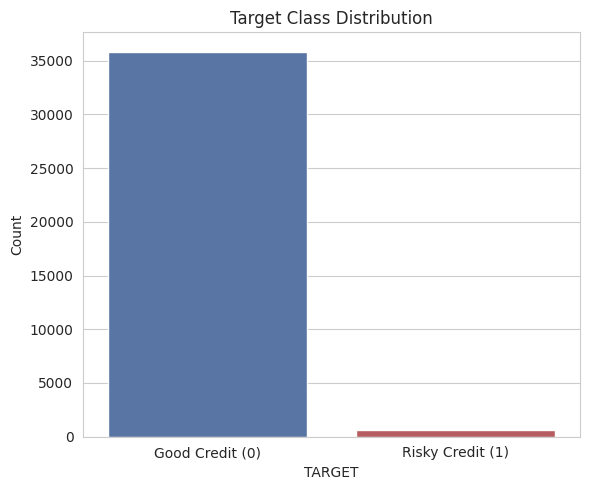

In [13]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=merged_df, x='TARGET', hue='TARGET', palette=['#4C72B0','#C44E52'], legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(['Good Credit (0)', 'Risky Credit (1)'])
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/target_distribution.png', dpi=100)
plt.show()

## 6. Feature Engineering

Raw columns are converted into more understandable features:
- `DAYS_BIRTH` (negative days) → `Age` (positive years)
- `DAYS_EMPLOYED` (with the 365243 sentinel for unemployed/retired
  applicants) → `Years_Employed`, with the sentinel converted to 0
- `OCCUPATION_TYPE` missing values filled with `"Unknown"`
- Columns renamed to readable names

We keep 13 meaningful features, within the recommended 10-15 range.

In [14]:
merged_df['Age'] = (-merged_df['DAYS_BIRTH'] / 365).astype(int)
merged_df['Years_Employed'] = merged_df['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else -x / 365).round(1)
merged_df['OCCUPATION_TYPE'] = merged_df['OCCUPATION_TYPE'].fillna('Unknown')

merged_df = merged_df.rename(columns={
    'CODE_GENDER': 'Gender',
    'FLAG_OWN_CAR': 'Own_Car',
    'FLAG_OWN_REALTY': 'Own_Realty',
    'CNT_CHILDREN': 'Children',
    'AMT_INCOME_TOTAL': 'Annual_Income',
    'NAME_INCOME_TYPE': 'Income_Type',
    'NAME_EDUCATION_TYPE': 'Education',
    'NAME_FAMILY_STATUS': 'Marital_Status',
    'NAME_HOUSING_TYPE': 'Housing_Type',
    'CNT_FAM_MEMBERS': 'Family_Size',
    'OCCUPATION_TYPE': 'Occupation_Type',
})

final_features = [
    'Gender', 'Own_Car', 'Own_Realty', 'Children', 'Annual_Income',
    'Income_Type', 'Education', 'Marital_Status', 'Housing_Type',
    'Age', 'Years_Employed', 'Family_Size', 'Occupation_Type', 'TARGET'
]
final_df = merged_df[final_features]

print("Final feature set shape:", final_df.shape)
print("Age range:", final_df['Age'].min(), "-", final_df['Age'].max())
print("Years_Employed range:", final_df['Years_Employed'].min(), "-", final_df['Years_Employed'].max())
final_df.head()

Final feature set shape: (36457, 14)
Age range: 20 - 68
Years_Employed range: 0.0 - 43.0


,Gender,Own_Car,Own_Realty,Children,Annual_Income,Income_Type,Education,Marital_Status,Housing_Type,Age,Years_Employed,Family_Size,Occupation_Type,TARGET
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32,12.4,2.0,Unknown,0
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32,12.4,2.0,Unknown,0
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,58,3.1,2.0,Security staff,0
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52,8.4,1.0,Sales staff,0
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52,8.4,1.0,Sales staff,0


In [15]:
final_df.to_csv('../data/final_features.csv', index=False)
print("Saved final_features.csv")

Saved final_features.csv


## 7. Exploratory Data Analysis

We visualize distributions of key features and their relationship with
the target class. **Note:** these charts show *associations*, not causal
relationships.

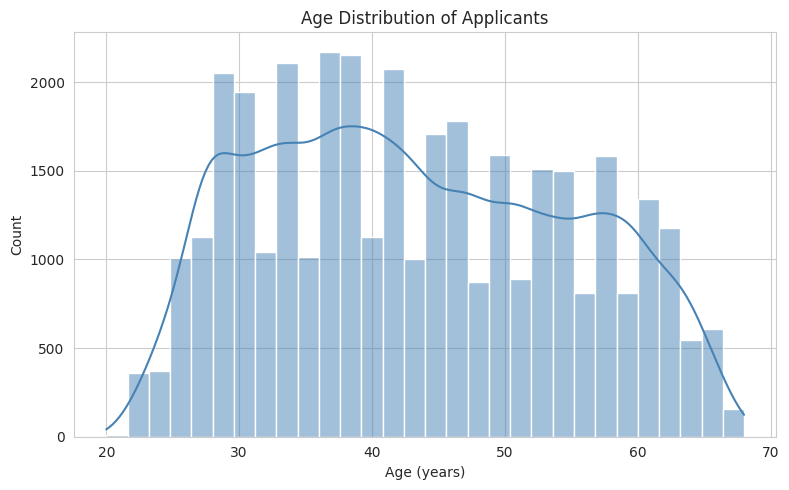

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(final_df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Applicants')
plt.xlabel('Age (years)')
plt.tight_layout()
plt.savefig('../images/age_distribution.png', dpi=100)
plt.show()

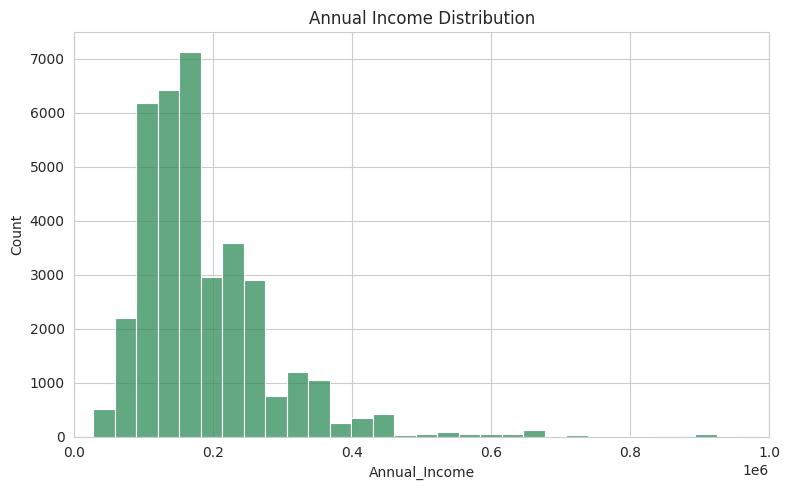

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(final_df['Annual_Income'], bins=50, color='seagreen')
plt.title('Annual Income Distribution')
plt.xlim(0, 1_000_000)
plt.tight_layout()
plt.savefig('../images/income_distribution.png', dpi=100)
plt.show()

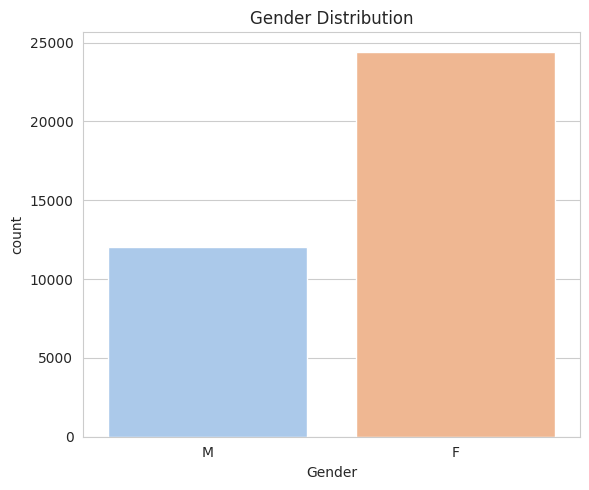

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(data=final_df, x='Gender', hue='Gender', palette='pastel', legend=False)
plt.title('Gender Distribution')
plt.tight_layout()
plt.savefig('../images/gender_distribution.png', dpi=100)
plt.show()

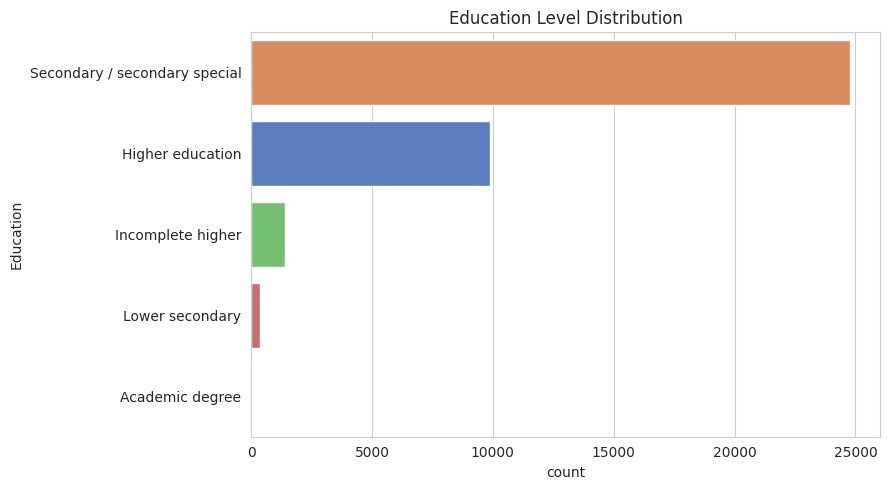

In [19]:
plt.figure(figsize=(9,5))
order = final_df['Education'].value_counts().index
sns.countplot(data=final_df, y='Education', order=order, hue='Education', palette='muted', legend=False)
plt.title('Education Level Distribution')
plt.tight_layout()
plt.savefig('../images/education_distribution.png', dpi=100)
plt.show()

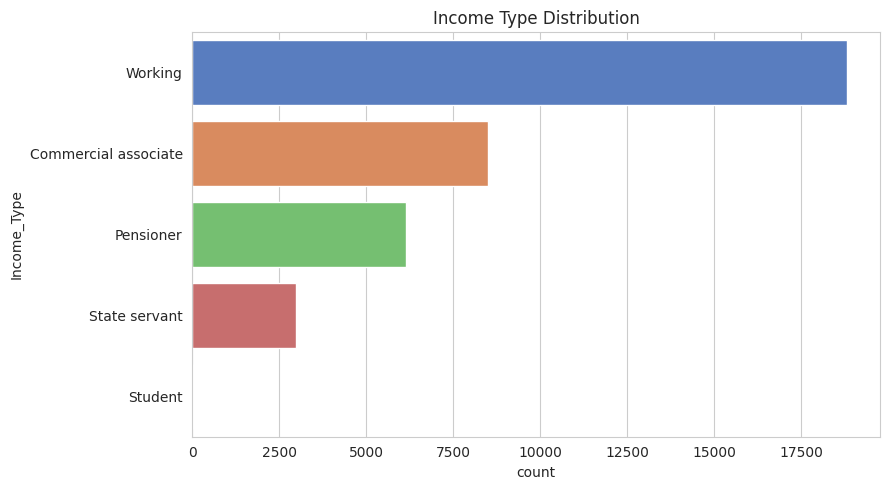

In [20]:
plt.figure(figsize=(9,5))
order = final_df['Income_Type'].value_counts().index
sns.countplot(data=final_df, y='Income_Type', order=order, hue='Income_Type', palette='muted', legend=False)
plt.title('Income Type Distribution')
plt.tight_layout()
plt.savefig('../images/income_type_distribution.png', dpi=100)
plt.show()

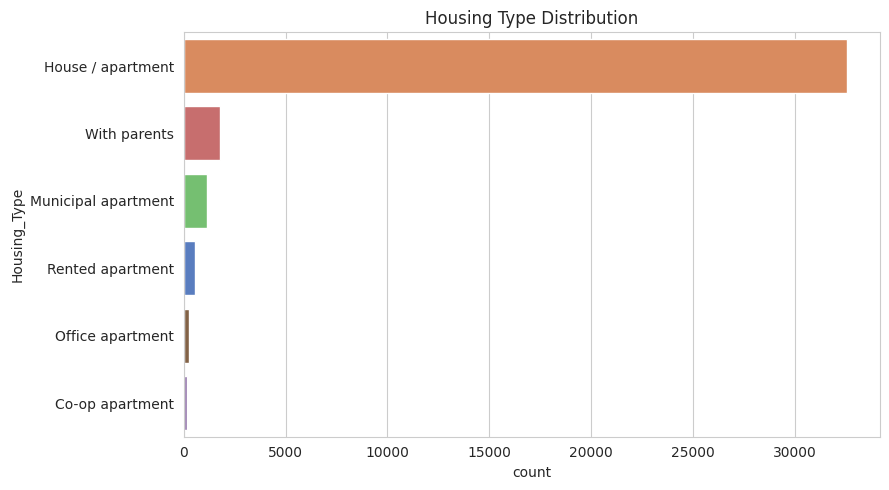

In [21]:
plt.figure(figsize=(9,5))
order = final_df['Housing_Type'].value_counts().index
sns.countplot(data=final_df, y='Housing_Type', order=order, hue='Housing_Type', palette='muted', legend=False)
plt.title('Housing Type Distribution')
plt.tight_layout()
plt.savefig('../images/housing_type_distribution.png', dpi=100)
plt.show()

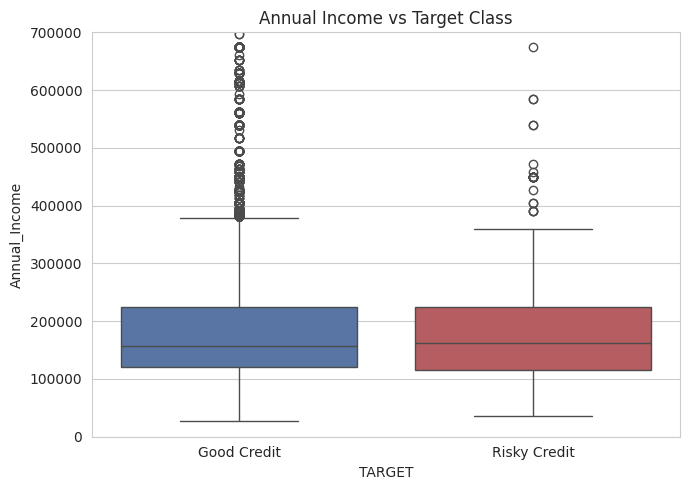

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(data=final_df, x='TARGET', y='Annual_Income', hue='TARGET', palette=['#4C72B0','#C44E52'], legend=False)
plt.ylim(0, 700000)
plt.xticks([0,1], ['Good Credit', 'Risky Credit'])
plt.title('Annual Income vs Target Class')
plt.tight_layout()
plt.savefig('../images/income_vs_target.png', dpi=100)
plt.show()

**Observation:** the analysis shows very little difference in income between the two classes — income alone does not strongly separate Good Credit from Risky Credit applicants in this dataset.

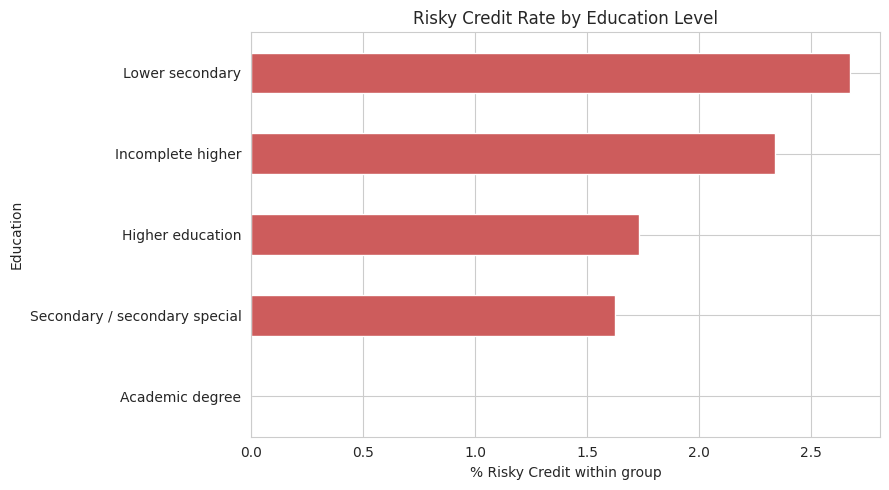

Education
Lower secondary                  2.673797
Incomplete higher                2.340426
Higher education                 1.733577
Secondary / secondary special    1.622472
Academic degree                  0.000000
Name: 1, dtype: float64

In [23]:
edu_target = pd.crosstab(final_df['Education'], final_df['TARGET'], normalize='index') * 100
plt.figure(figsize=(9,5))
edu_target[1].sort_values().plot(kind='barh', color='indianred')
plt.xlabel('% Risky Credit within group')
plt.title('Risky Credit Rate by Education Level')
plt.tight_layout()
plt.savefig('../images/education_vs_target.png', dpi=100)
plt.show()
edu_target[1].sort_values(ascending=False)

**Observation:** the analysis shows a mild association between lower education levels and a higher risky-credit rate.

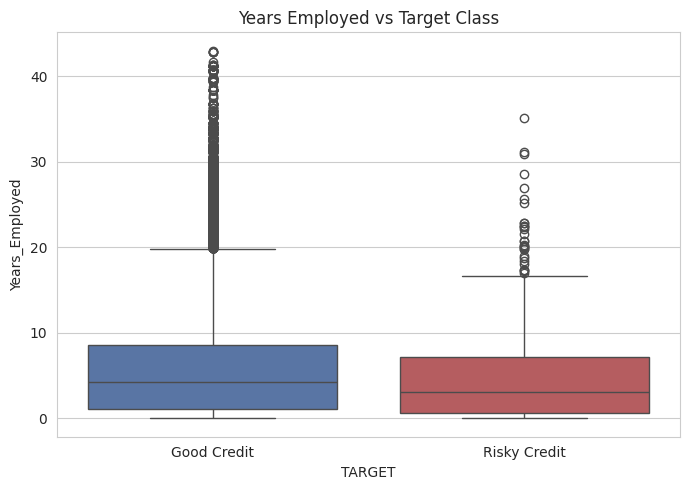

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,35841.0,6.047222,6.497331,0.0,1.100,4.3,8.6,43.0
1,616.0,4.907955,5.564249,0.0,0.675,3.1,7.2,35.1


In [24]:
plt.figure(figsize=(7,5))
sns.boxplot(data=final_df, x='TARGET', y='Years_Employed', hue='TARGET', palette=['#4C72B0','#C44E52'], legend=False)
plt.xticks([0,1], ['Good Credit', 'Risky Credit'])
plt.title('Years Employed vs Target Class')
plt.tight_layout()
plt.savefig('../images/employment_vs_target.png', dpi=100)
plt.show()
final_df.groupby('TARGET')['Years_Employed'].describe()

**Observation:** the analysis shows applicants with a shorter employment history have some association with a higher risky-credit rate, though the distributions overlap considerably.

## 8. Data Preprocessing

Numeric features are scaled with `StandardScaler`; categorical features
are one-hot encoded with `OneHotEncoder`. These are combined into a single
`ColumnTransformer`, which we later wrap together with the classifier in
one `Pipeline` — this guarantees the exact same preprocessing is applied
during training and during live predictions in the Streamlit app.

In [25]:
X = final_df.drop(columns=['TARGET'])
y = final_df['TARGET']

categorical_cols = ['Gender', 'Own_Car', 'Own_Realty', 'Income_Type',
                     'Education', 'Marital_Status', 'Housing_Type', 'Occupation_Type']
numeric_cols = ['Children', 'Annual_Income', 'Age', 'Years_Employed', 'Family_Size']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
])

## 9. Train/Test Split

We use an 80/20 split with `random_state=42` for reproducibility. Because
of the severe class imbalance found earlier, we **stratify** on the
target so both sets keep the same class ratio.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print()
print("Train class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print()
print("Test class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (29165, 13)  Test shape: (7292, 13)

Train class distribution:
TARGET
0    98.309618
1     1.690382
Name: proportion, dtype: float64

Test class distribution:
TARGET
0    98.31322
1     1.68678
Name: proportion, dtype: float64


## 10. Model Training

We train three beginner-friendly classification models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

All three use `class_weight='balanced'` to address the severe class
imbalance discovered earlier — this up-weights the minority (Risky
Credit) class during training instead of letting the model ignore it.

Each model is wrapped together with the preprocessing step in one
`Pipeline`, fitted only on the training data (to avoid data leakage).

In [27]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

fitted_pipelines = {}
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"{name} trained.")

Logistic Regression trained.


Decision Tree trained.


Random Forest trained.


## 11. Model Evaluation & Comparison

We evaluate all three models on the held-out test set using Accuracy,
Precision, Recall, and F1 Score (focused on the Risky Credit class),
plus a confusion matrix for each.

**Why not just accuracy?** With ~98% of applicants labeled Good Credit, a
model that always predicts "Good Credit" would score ~98% accuracy while
being completely useless at catching risky applicants. Precision, recall,
and F1 on the minority class tell us whether the model is actually doing
useful work.

In [28]:
comparison_rows = []

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm}
    comparison_rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Risky Credit']))
    print("Confusion Matrix:")
    print(cm)
    print()

comparison_table = pd.DataFrame(comparison_rows).set_index('Model')
comparison_table

=== Logistic Regression ===
              precision    recall  f1-score   support

 Good Credit       0.99      0.60      0.75      7169
Risky Credit       0.02      0.50      0.04       123

    accuracy                           0.60      7292
   macro avg       0.50      0.55      0.39      7292
weighted avg       0.97      0.60      0.73      7292

Confusion Matrix:
[[4308 2861]
 [  62   61]]

=== Decision Tree ===
              precision    recall  f1-score   support

 Good Credit       0.99      0.96      0.98      7169
Risky Credit       0.16      0.43      0.24       123

    accuracy                           0.95      7292
   macro avg       0.58      0.70      0.61      7292
weighted avg       0.98      0.95      0.96      7292

Confusion Matrix:
[[6900  269]
 [  70   53]]



=== Random Forest ===


              precision    recall  f1-score   support

 Good Credit       0.99      0.97      0.98      7169
Risky Credit       0.18      0.39      0.25       123

    accuracy                           0.96      7292
   macro avg       0.59      0.68      0.61      7292
weighted avg       0.98      0.96      0.97      7292

Confusion Matrix:
[[6954  215]
 [  75   48]]



,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.599150,0.020876,0.495935,0.040066
Decision Tree,0.953511,0.164596,0.430894,0.238202
Random Forest,0.960230,0.182510,0.390244,0.248705


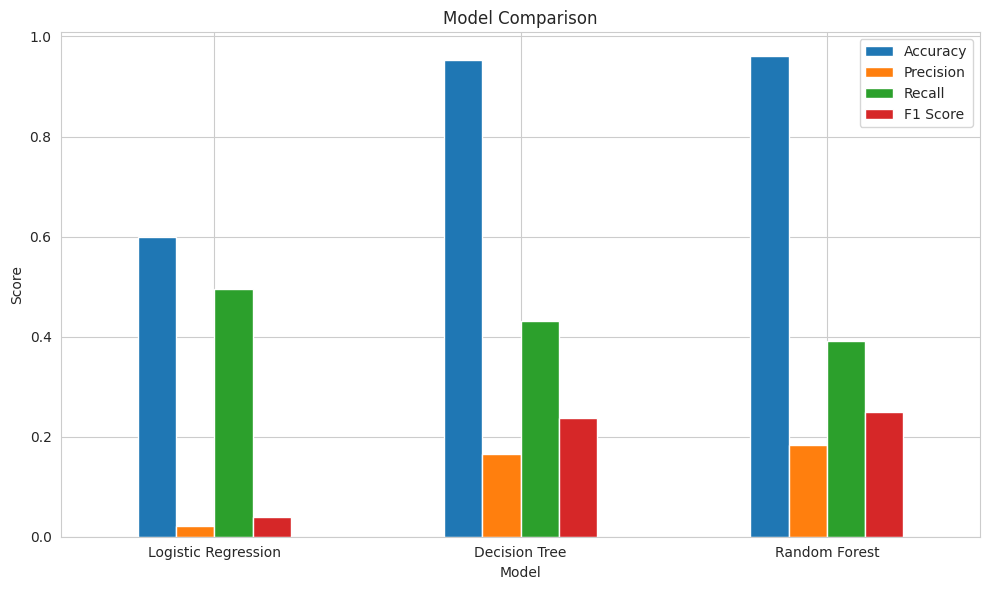

In [29]:
comparison_table.plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=100)
plt.show()

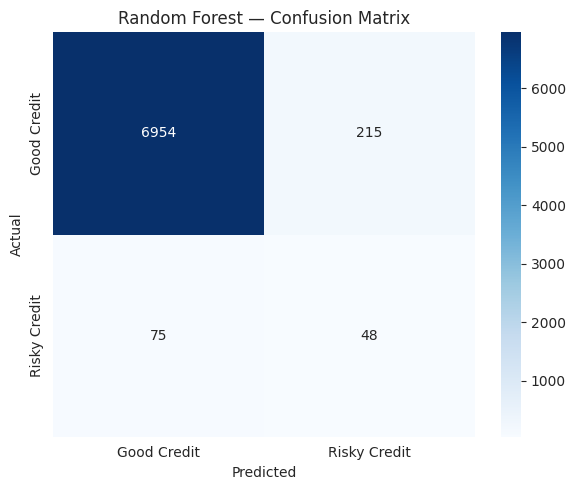

In [30]:
best_cm = results['Random Forest']['confusion_matrix']
plt.figure(figsize=(6,5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Credit', 'Risky Credit'],
            yticklabels=['Good Credit', 'Risky Credit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=100)
plt.show()

## 12. Final Model Selection & Saving

**Selection rationale (based on the actual results above, not assumed):**
Random Forest achieves the highest F1 score among the three models,
meaning it has the best balance of precision and recall on the minority
(Risky Credit) class — the metric that matters most given the severe
class imbalance. Logistic Regression performs poorly here because the
relationship between features and risk is not well captured by a linear
decision boundary. Decision Tree is close to Random Forest but is
slightly outperformed on F1 and precision.

We save the **entire pipeline** (preprocessing + classifier together)
with Joblib, so the Streamlit app can load one file and get identical
preprocessing behavior with no risk of train/serve mismatch.

In [31]:
final_model_name = comparison_table['F1 Score'].idxmax()
print("Final selected model:", final_model_name)

final_pipeline = fitted_pipelines[final_model_name]
joblib.dump(final_pipeline, '../models/credit_card_model.pkl')
print("Saved to ../models/credit_card_model.pkl")

Final selected model: Random Forest
Saved to ../models/credit_card_model.pkl


In [32]:
# Sanity check: reload from disk and predict on a sample applicant
reloaded_model = joblib.load('../models/credit_card_model.pkl')

sample_applicant = pd.DataFrame([{
    'Gender': 'M', 'Own_Car': 'Y', 'Own_Realty': 'Y', 'Children': 0,
    'Annual_Income': 200000.0, 'Income_Type': 'Working',
    'Education': 'Higher education', 'Marital_Status': 'Married',
    'Housing_Type': 'House / apartment', 'Age': 35, 'Years_Employed': 5.0,
    'Family_Size': 2.0, 'Occupation_Type': 'Managers'
}])

prediction = reloaded_model.predict(sample_applicant)[0]
probability = reloaded_model.predict_proba(sample_applicant)[0]

print("Predicted class:", "Risky Credit" if prediction == 1 else "Good Credit")
print("Probabilities [Good, Risky]:", probability)

Predicted class: Good Credit
Probabilities [Good, Risky]: [0.99064352 0.00935648]


## Conclusion

This notebook took raw applicant and credit-history data through the full
pipeline: cleaning, merging, target creation, feature engineering, EDA,
preprocessing, training three models, and selecting a final model based
on real evaluation metrics. The resulting `credit_card_model.pkl` is used
directly by the Streamlit application (`app.py`) to serve live
predictions.

See the project `README.md` for the full write-up, including limitations
and future improvements.